In [3]:
import tensorflow as tf    # tensorflow의 별명은 tf로 한다

print(tf.__version__)      # version 앞뒤로 두 개의 밑줄을 사용한다

2.20.0


In [4]:
# tensorflow와 tf.keras를 임포트
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

# MNIST 데이터를 학습용, 테스트 데이터로 구분하여 읽어옴
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [5]:
print(train_images.shape)

(60000, 28, 28)


In [5]:
print(train_labels.shape)

(60000,)


In [7]:
print(test_images.shape)

(10000, 28, 28)


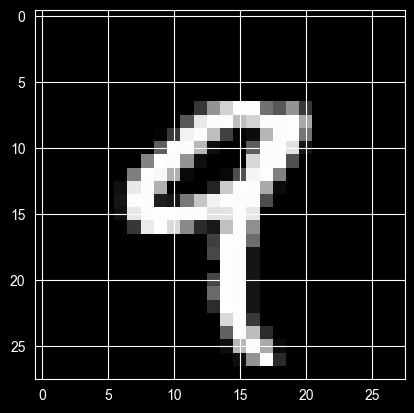

In [8]:
image =train_images[4]
plt.imshow(image,cmap='gray')
plt.show()

In [10]:
print(train_labels[4])

9


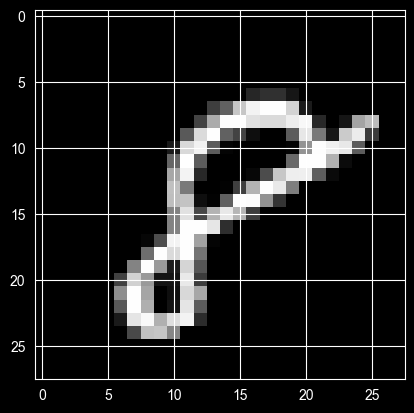

8


In [12]:
image =train_images[59999]
plt.imshow(image,cmap='gray')
plt.show()
print(train_labels[59999])

In [13]:
num = train_images[0]
for i in range(28):
    for j in range(28):
        print('{:4d}'.format(num[i][j]), end='')
    print()

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

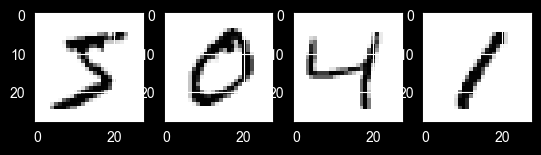

In [14]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 4, 1)
ax2 = fig.add_subplot(1, 4, 2)
ax3 = fig.add_subplot(1, 4, 3)
ax4 = fig.add_subplot(1, 4, 4)

ax1.imshow(train_images[0], cmap='Greys') # 첫 번째 훈련용 데이터
ax2.imshow(train_images[1], cmap='Greys') # 두 번째 훈련용 데이터
ax3.imshow(train_images[2], cmap='Greys') # 세 번째 훈련용 데이터
ax4.imshow(train_images[3], cmap='Greys') # 네 번째 훈련용 데이터
plt.show()

In [15]:
print('train_labels[:4] =', train_labels[:4])

train_labels[:4] = [5 0 4 1]


In [18]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

(train_images, test_images) = (train_images / 255, test_images / 255)

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
     keras.layers.Dense(128, activation='relu'),
     keras.layers.Dense(56, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [19]:
model.summary()   # 모델의 구조를 요약하여 살펴보자

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 56)             │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,650 (943.95 KB)

 Trainable params: 241,650 (943.95 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9891 - loss: 0.0353
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9912 - loss: 0.0279
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9922 - loss: 0.0249
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9924 - loss: 0.0241
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9934 - loss: 0.0206


In [23]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\n테스트 정확도:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9805 - loss: 0.0912

테스트 정확도: 0.9804999828338623


In [25]:
model.save("my_first_DNN_model.keras")

In [27]:
loaded_model = keras.models.load_model("my_first_DNN_model.keras")
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 56)             │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 724,952 (2.77 MB)

 Trainable params: 241,650 (943.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 483,302 (1.84 MB)

In [28]:
test_images.shape

(10000, 28, 28)

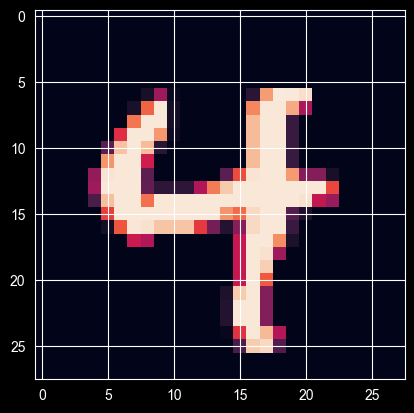

In [38]:
randIdx = np.random.randint(0, 6000)  # 6000개의 테스트 이미지 중 하나를 선택
rand_test_images = test_images[randIdx]
plt.imshow(test_images[randIdx])
plt.show()

In [39]:
predict_imge=model.predict(rand_test_images[np.newaxis,:])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [40]:
print(predict_imge)

[[1.8307207e-15 7.7674971e-11 2.5387786e-14 4.1210448e-16 1.0000000e+00
  4.6615374e-14 1.9004207e-14 4.2088513e-10 1.1933774e-13 2.2767825e-08]]


In [41]:
print(predict_imge.argmax())

4


In [14]:
# MNIST 데이터를 학습용, 테스트 데이터로 구분하여 읽어옴
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

(train_images, test_images) = (train_images / 255, test_images / 255)

#model 신경망 객체가 됨
model = keras.Sequential([ #모델구조 레이어를 위에서 아래로 쌓기위해 필요함
    keras.layers.Input(shape=(28, 28)),
    #앞으로 들어올 데이터는 28×28이다”라고 모델에 알려주는 역할.
    #Flatten 후: (784,) 로 바꿈(28×28 = 784 픽셀을 한 줄로 쭉 펴는 것)
    keras.layers.Flatten(),
    #다음 레이어가 Dense(완전연결층)인데 Dense는 기본적으로 1차원 벡터 입력을 받는다
    keras.layers.Dense(256, activation='relu'),
    #256개의 뉴런으로 계산해서 새로운 특징(feature)을 뽑아냄
    #relu로 비선형성을 줘서 복잡한 패턴을 학습 가능하게 함
    #y = relu(Wx + b)
    #여기서 W는 (784 × 256) 가중치 행렬이라고 보면 돼.
    #Wx + b만 보면 “선형(정확히는 affine 변환)”**이 맞아.
    #뒤에 relu()를 붙이면 전체는 비선형이 돼.



    #**“이미지에서 중요한 특징을 학습하는 층”**
    keras.layers.Dense(10, activation='softmax')
    #뉴런 10개 = 숫자 0~9 각각의 점수(확률)를 만들기 위해서
    #softmax는 10개 값을 확률처럼 바꿔줌:각 값이 0~1 사이 전부 더하면 1
])
model.summary()   # 모델의 구조를 요약하여 살펴보자

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam', #경사하강법 기본
              loss='sparse_categorical_crossentropy',
              #손실함수 sparse_...정수(0~9) 로 들어올 때 사용
              #loss는 “학습이 최소화해야 하는 목표(필수)”
              metrics=['accuracy']) #정확도
                #metrics는 “사람이 보기 좋은 성적표(옵션)” 느낌
model.fit(train_images, train_labels, epochs=5) #학습 데이터를 전체 1바퀴 도는 것 = 1 epoch

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9335 - loss: 0.2280
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9714 - loss: 0.0948
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9811 - loss: 0.0622
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9862 - loss: 0.0450
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9895 - loss: 0.0334


In [18]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
#verbose=2 : 진행바 없이 줄(line) 단위로 간단히 출력
print('\n테스트 정확도:', test_acc)

313/313 - 0s - 2ms/step - accuracy: 0.9778 - loss: 0.0711

테스트 정확도: 0.9778000116348267


In [19]:
# MNIST 데이터를 학습용, 테스트 데이터로 구분하여 읽어옴
mnist = keras.datasets.mnist
((train_images, train_labels), (test_images, test_labels)) = mnist.load_data()

(train_images, test_images) = (train_images / 255, test_images / 255)

model = keras.Sequential([
   keras.layers.Input(shape=(28, 28)),
   keras.layers.Flatten(),
   keras.layers.Dense(256, activation='relu'),
   keras.layers.Dense(128, activation='relu'),
   keras.layers.Dense(100, activation='relu'),
   keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10, verbose=1)

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print('\n테스트 정확도:', test_acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9379 - loss: 0.2089
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9717 - loss: 0.0907
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9787 - loss: 0.0660
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9845 - loss: 0.0491
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0407
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0327
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9911 - loss: 0.0279
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0269
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9932 - loss: 0.0222
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9939 - loss: 0.0196

테스트 정확도: 0.9763000011444092
